---
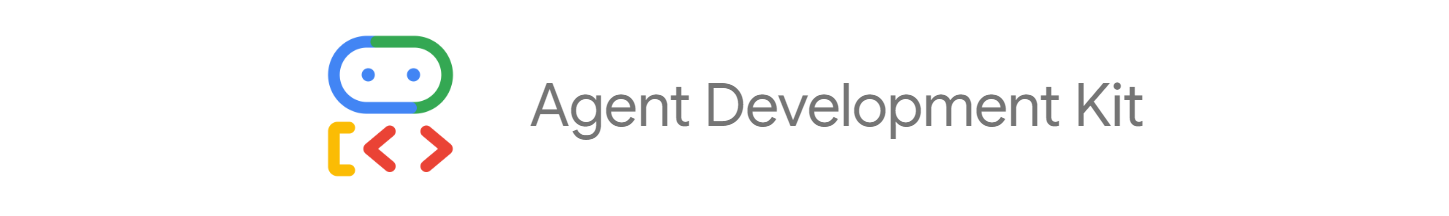

---

# Artifacts

In ADK, **Artifacts** represent a crucial mechanism for managing named, versioned binary data associated either with a specific user interaction session or persistently with a user across multiple sessions. They allow your agents and tools to handle data beyond simple text strings, enabling richer interactions involving files, images, audio, and other binary formats.

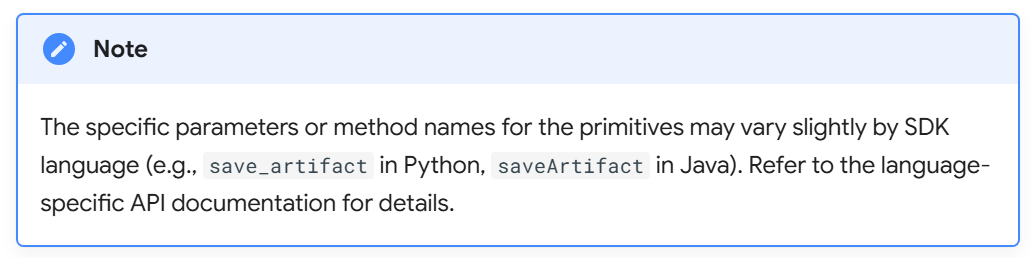

---

## What are Artifacts?
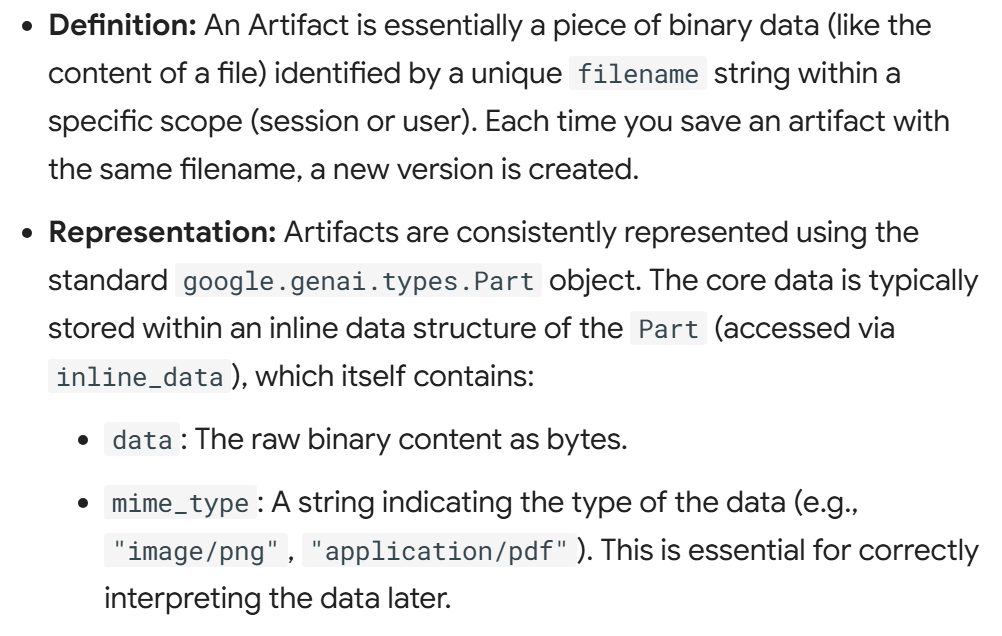

```Python
# Example of how an artifact might be represented as a types.Part
import google.genai.types as types

# Assume 'image_bytes' contains the binary data of a PNG image
image_bytes = b'\x89PNG\r\n\x1a\n...' # Placeholder for actual image bytes

image_artifact = types.Part(
    inline_data=types.Blob(
        mime_type="image/png",
        data=image_bytes
    )
)

# You can also use the convenience constructor:
# image_artifact_alt = types.Part.from_bytes(data=image_bytes, mime_type="image/png")

print(f"Artifact MIME Type: {image_artifact.inline_data.mime_type}")
print(f"Artifact Data (first 10 bytes): {image_artifact.inline_data.data[:10]}...")
```

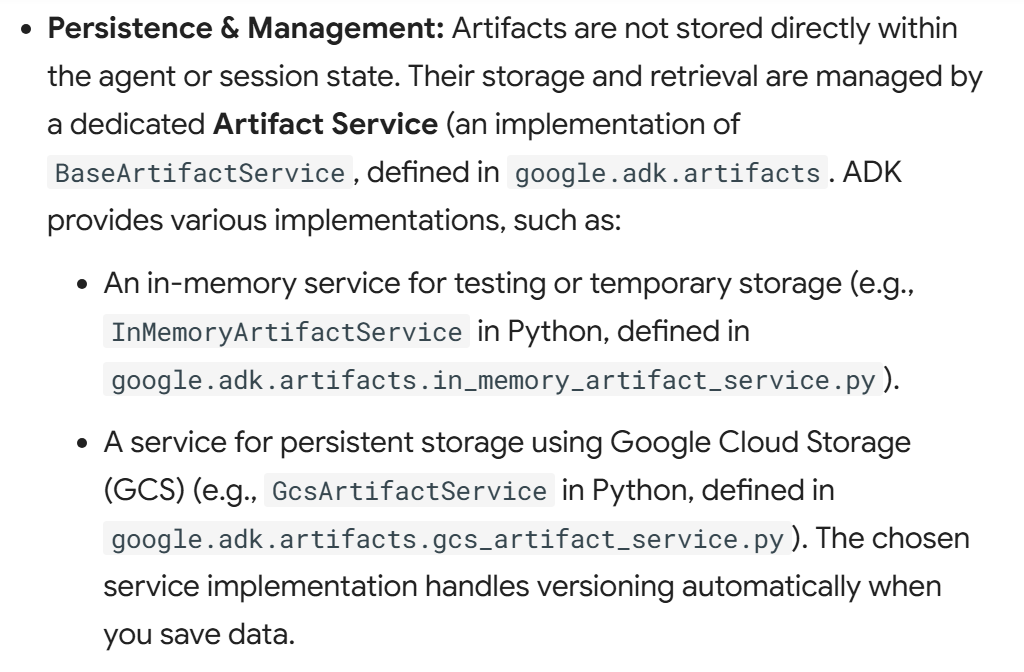

----

## Why Use Artifacts?
While session `state` is suitable for storing small pieces of configuration or conversational context (like strings, numbers, booleans, or small dictionaries/lists), Artifacts are designed for scenarios involving binary or large data:

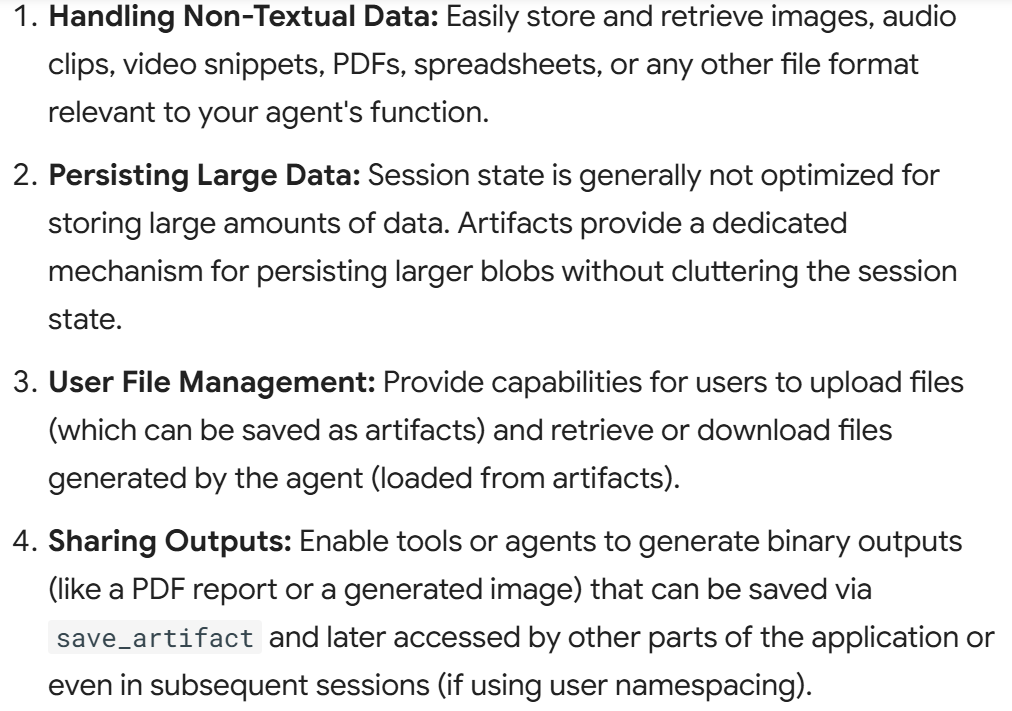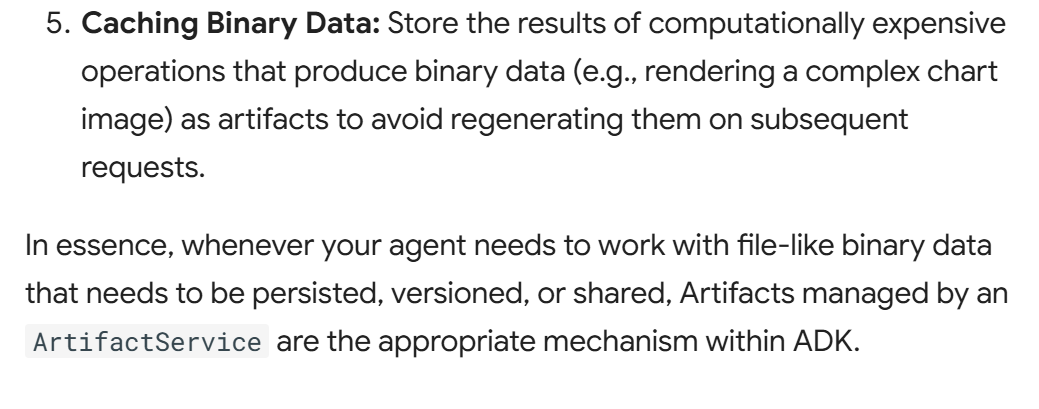

---

## Common Use Cases
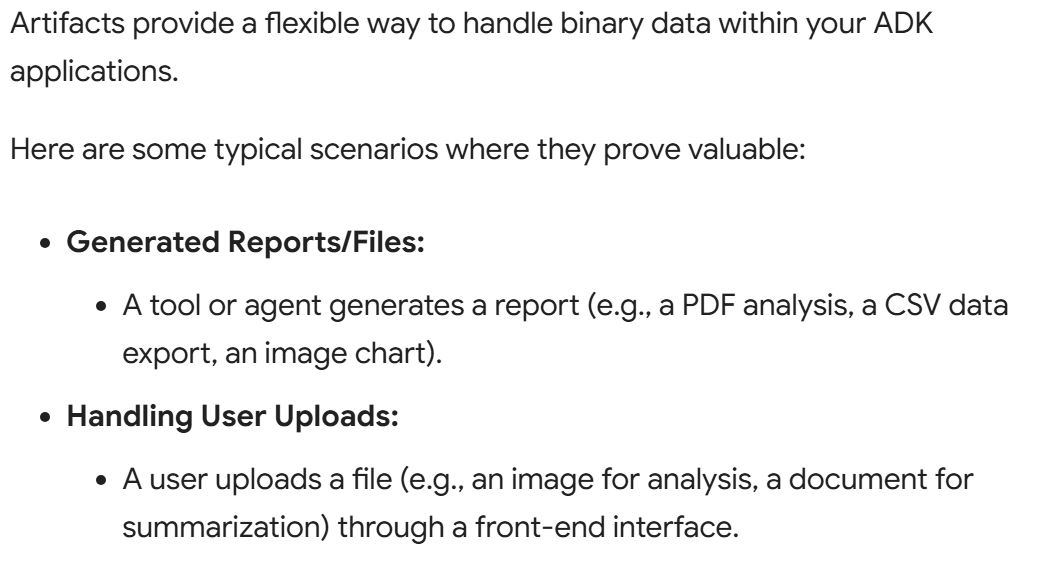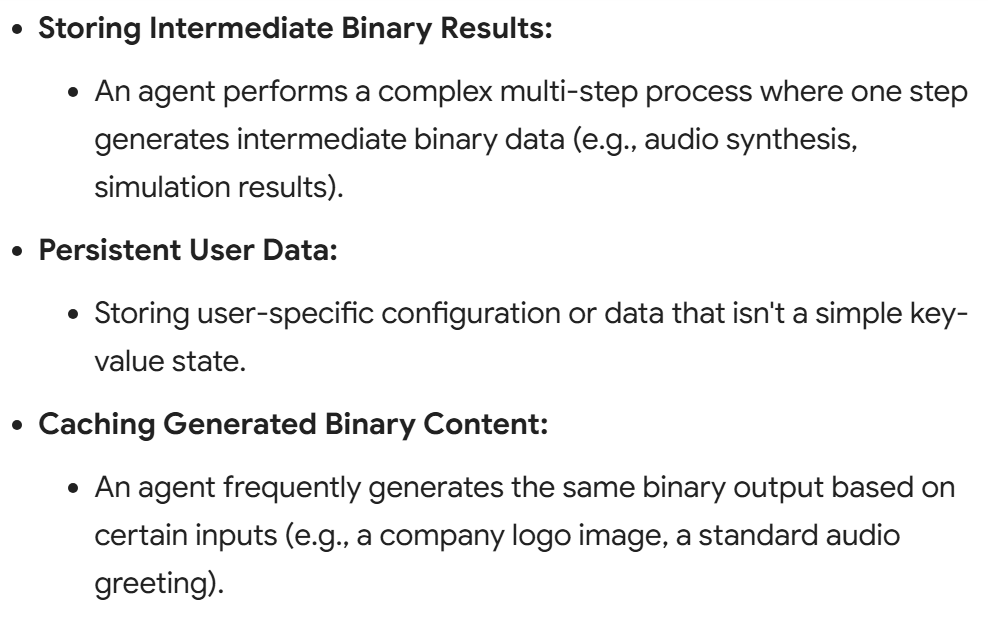

---

## Core Concepts
Understanding artifacts involves grasping a few key components: the service that manages them, the data structure used to hold them, and how they are identified and versioned.

### Artifact Service (`BaseArtifactService`)
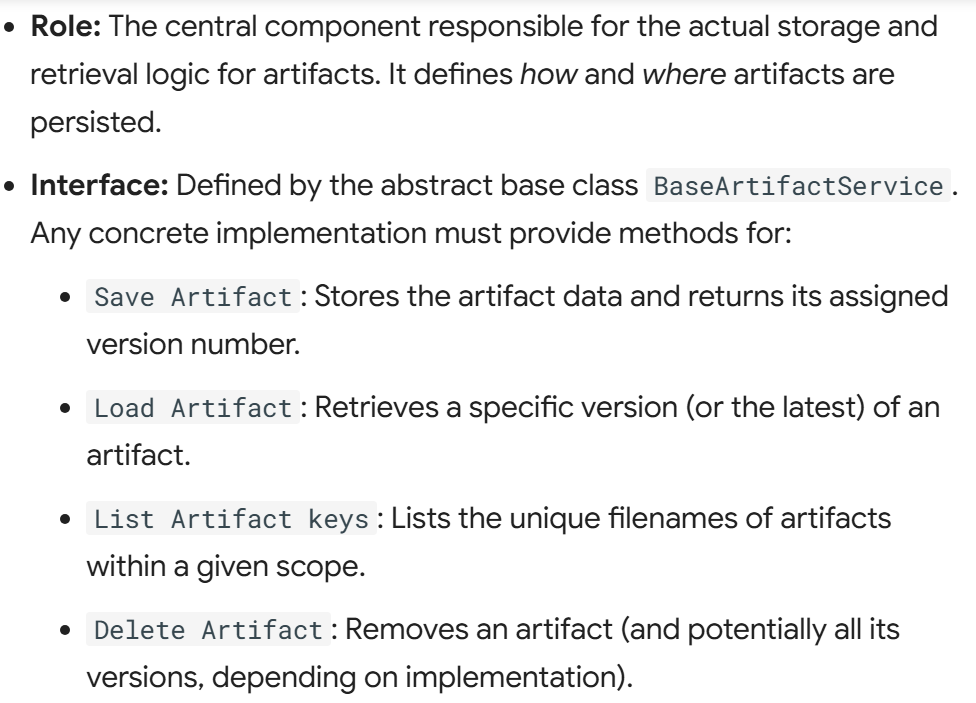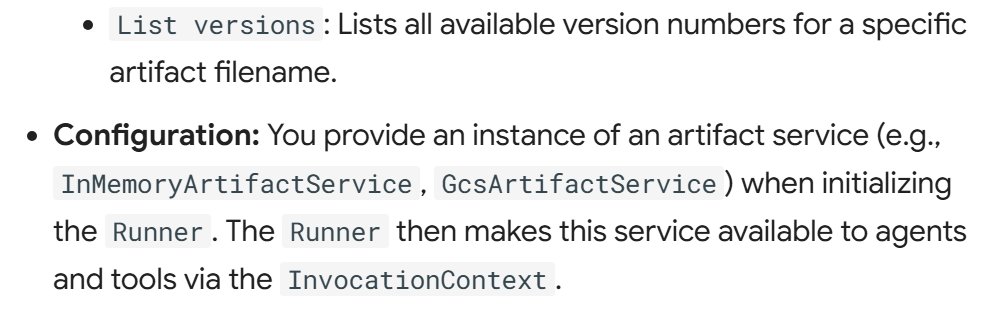

```Python
from google.adk.runners import Runner
from google.adk.artifacts import InMemoryArtifactService # Or GcsArtifactService
from google.adk.agents import LlmAgent # Any agent
from google.adk.sessions import InMemorySessionService

# Example: Configuring the Runner with an Artifact Service
my_agent = LlmAgent(name="artifact_user_agent", model="gemini-2.0-flash")
artifact_service = InMemoryArtifactService() # Choose an implementation
session_service = InMemorySessionService()

runner = Runner(
    agent=my_agent,
    app_name="my_artifact_app",
    session_service=session_service,
    artifact_service=artifact_service # Provide the service instance here
)
# Now, contexts within runs managed by this runner can use artifact methods
```

### Artifact Data
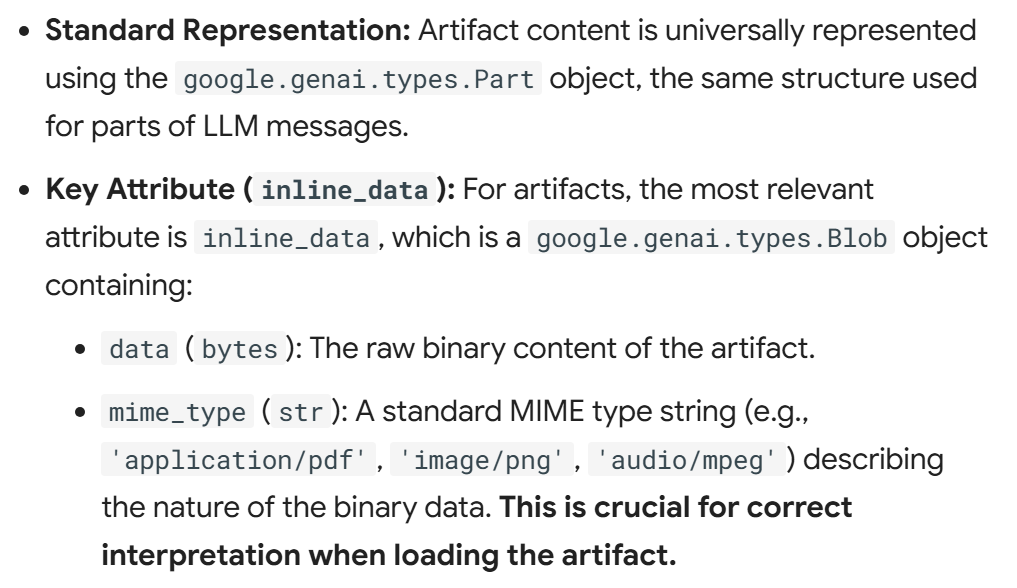

```Python
import google.genai.types as types

# Example: Creating an artifact Part from raw bytes
pdf_bytes = b'%PDF-1.4...' # Your raw PDF data
pdf_mime_type = "application/pdf"

# Using the constructor
pdf_artifact_py = types.Part(
    inline_data=types.Blob(data=pdf_bytes, mime_type=pdf_mime_type)
)

# Using the convenience class method (equivalent)
pdf_artifact_alt_py = types.Part.from_bytes(data=pdf_bytes, mime_type=pdf_mime_type)

print(f"Created Python artifact with MIME type: {pdf_artifact_py.inline_data.mime_type}")
```

### Filename
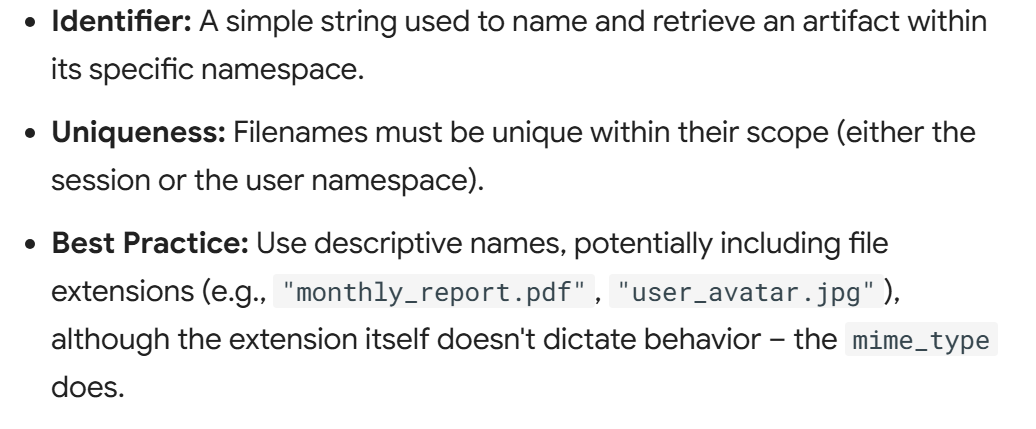

### Versioning
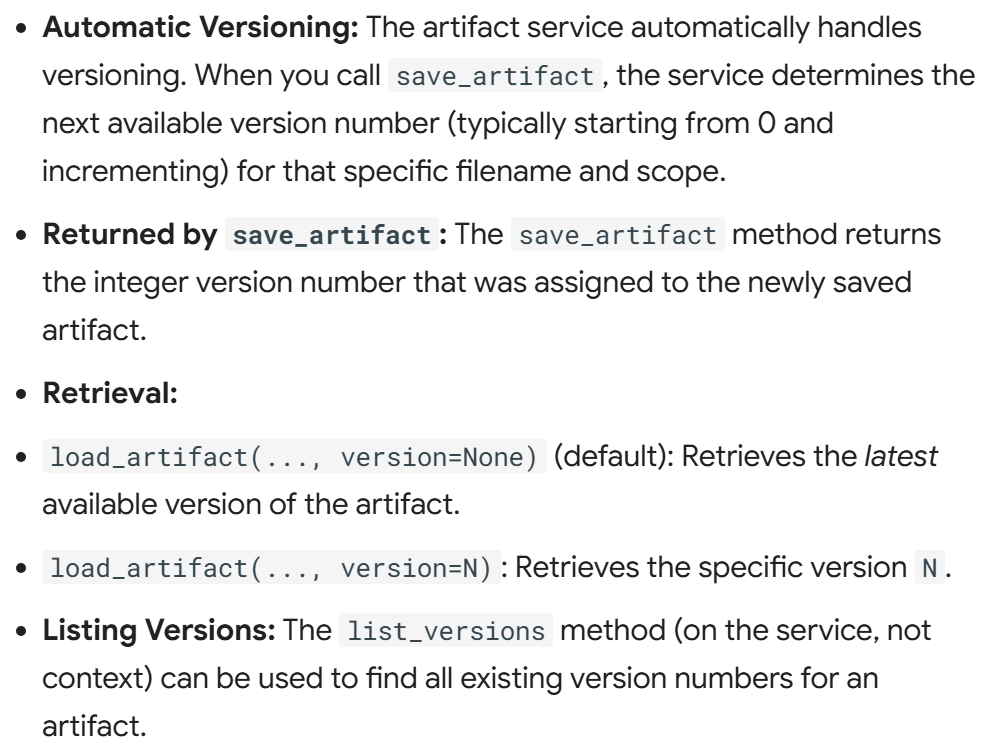

### Namespacing (Session vs. User)
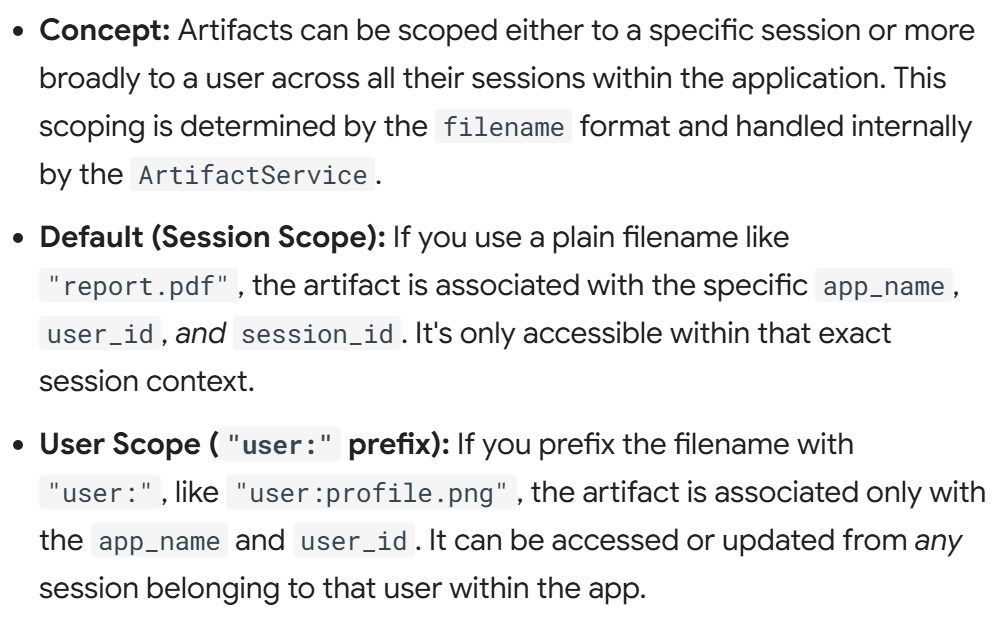

```Python
# Example illustrating namespace difference (conceptual)

# Session-specific artifact filename
session_report_filename = "summary.txt"

# User-specific artifact filename
user_config_filename = "user:settings.json"

# When saving 'summary.txt' via context.save_artifact,
# it's tied to the current app_name, user_id, and session_id.

# When saving 'user:settings.json' via context.save_artifact,
# the ArtifactService implementation should recognize the "user:" prefix
# and scope it to app_name and user_id, making it accessible across sessions for that user.
```

> These core concepts work together to provide a flexible system for managing binary data within the ADK framework.

---

## Interacting with Artifacts (via Context Objects)
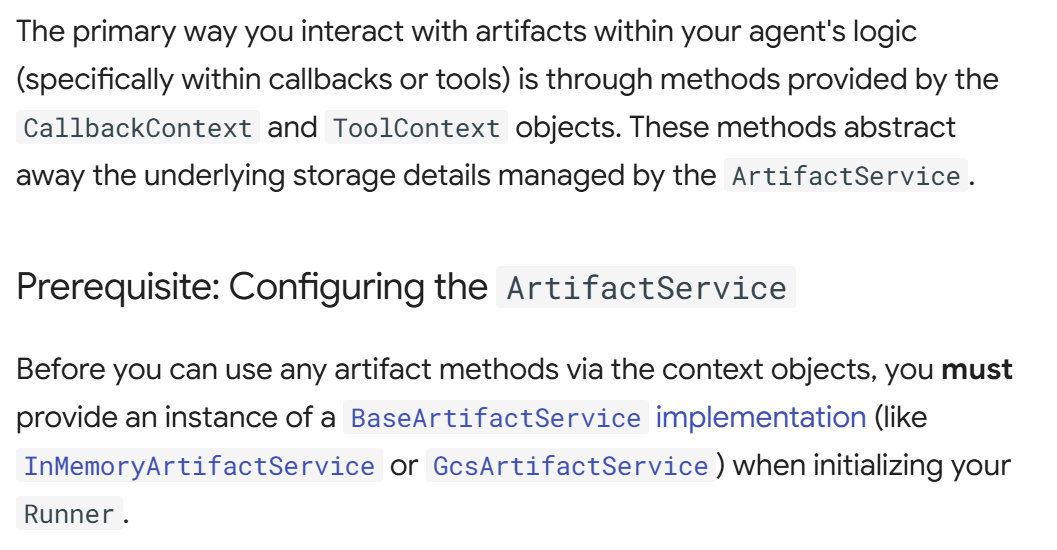

#### `In Python, you provide this instance when initializing your Runner.`

```Python
from google.adk.runners import Runner
from google.adk.artifacts import InMemoryArtifactService # Or GcsArtifactService
from google.adk.agents import LlmAgent
from google.adk.sessions import InMemorySessionService

# Your agent definition
agent = LlmAgent(name="my_agent", model="gemini-2.0-flash")

# Instantiate the desired artifact service
artifact_service = InMemoryArtifactService()

# Provide it to the Runner
runner = Runner(
    agent=agent,
    app_name="artifact_app",
    session_service=InMemorySessionService(),
    artifact_service=artifact_service # Service must be provided here
)
```

> If no artifact_service is configured in the InvocationContext (which happens if it's not passed to the Runner), calling save_artifact, load_artifact, or list_artifacts on the context objects will raise a ValueError.